(140,)
(140,)


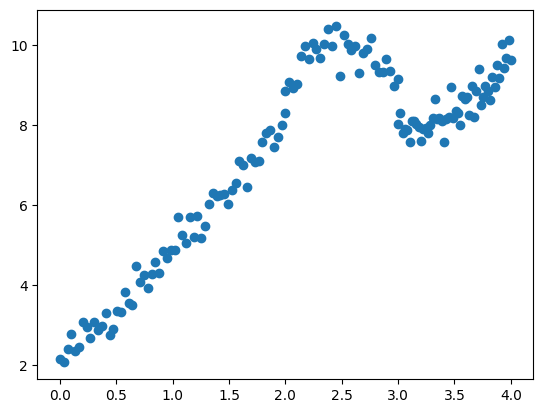

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv("polynomial_data.csv")

x_train = data["x_train"].values
y_train = data["y_train"].values

print(x_train.shape) # (140,)
print(y_train.shape) # (140,)

plt.scatter(x_train, y_train)
x=x_train
y=y_train

In [97]:
x.shape

(140,)

In [98]:
# x=x.reshape(-1,1)
# y=y.reshape(-1,1)
# w=np.random.randn(1,x.shape[1])
# b=0
# epsilon=1
# c=1
# f_x=(w@x.T+b).T
# loss_history=[]
# alpha=0.01

# for epoch in range(100):
#     margin = np.maximum(0,np.abs(f_x-y)-epsilon)
#     loss = (1/2)*np.sum(np.square(w))+c*np.mean(margin)
#     loss_history.append(loss)
#     mask1 =(margin>0).flatten()
#     mask2 =(margin<0).flatten() 
    
#     djdw = w + c * np.mean(x[mask1] * y[mask1], axis=0, keepdims=True)- c * np.mean(x[mask2] * y[mask2], axis=0, keepdims=True)
#     djdb=c*sum(mask1)-c*sum(mask2)
    
#     w = w - alpha * djdw
#     b = b - alpha * djdb
# plt.plot(loss_history)

In [99]:
from sklearn.preprocessing import PolynomialFeatures

X=x.reshape(-1,1)
y=y.reshape(-1,1)

x = (X - X.mean(axis=0))/X.std(axis=0)

poly = PolynomialFeatures(degree=8, include_bias=False)
x = poly.fit_transform(x)

In [100]:
x.shape

(140, 8)

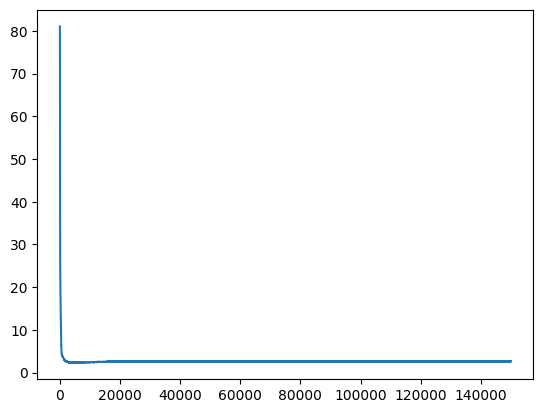

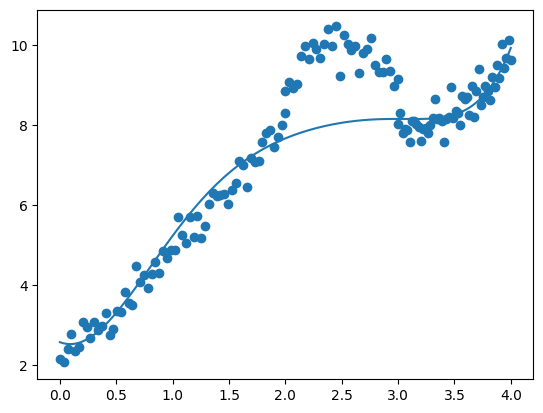

In [101]:
w=np.random.randn(1,x.shape[1])
b=0
epsilon=1
c=10

loss_history=[]
alpha=0.0001
m=x.shape[0]
for epoch in range(150000):
    f_x=(w@x.T+b).T
    margin = np.maximum(0,np.abs(f_x-y)-epsilon)
    loss = (1/2)*np.sum(np.square(w))+c*np.mean(margin)
    loss_history.append(loss)
    
    mask_pos =((f_x-y)>0).flatten()
    mask_neg =((f_x-y)<0).flatten() 
    
    djdw = w + (c * np.sum(x[mask_pos] , axis=0, keepdims=True) - c * np.sum(x[mask_neg] ,axis=0, keepdims=True))/m
    djdb = c*np.sum(mask_pos)-c*np.sum(mask_neg)
    
    w = w - alpha * djdw
    b = b - alpha * djdb
plt.plot(loss_history)
plt.show()
plt.scatter(X,y)
plt.plot(X,f_x)
plt.show()